# Lab assignment №1, part 3

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the third part of the assignment. First and second parts are waiting for you in the same directory.*__

##  Part 3. SVM and kernels

Kernels concept get adopted in variety of ML algorithms (e.g. Kernel PCA, Gaussian Processes, kNN, ...).

So in this task you are to examine kernels for SVM algorithm applied to rather simple artificial datasets.

To make it clear: we will work with the classification problem through the whole notebook.

In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

Let's generate our dataset and take a look on it.

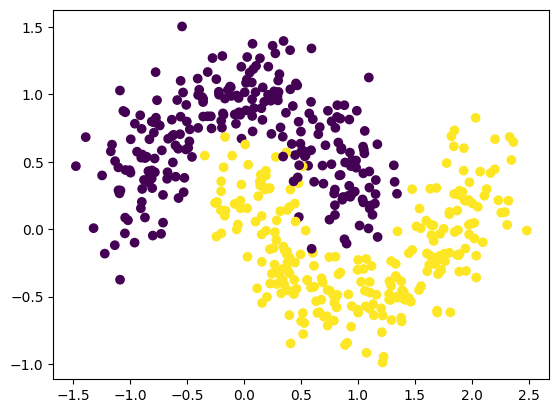

In [2]:
moons_points, moons_labels = make_moons(n_samples=500, noise=0.2, random_state=42)
plt.scatter(moons_points[:, 0], moons_points[:, 1], c=moons_labels)

In [4]:
moons_points.shape

(500, 2)

## 1.1 Pure models.
First let's try to solve this case with good old Logistic Regression and simple (linear kernel) SVM classifier.

Train LR and SVM classifiers (choose params by hand, no CV or intensive grid search neeeded) and plot their decision regions. Calculate one preffered classification metric.

Describe results in one-two sentences.

_Tip:_ to plot classifiers decisions you could use either sklearn examples ([this](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_alpha.html#sphx-glr-auto-examples-neural-networks-plot-mlp-alpha-py) or any other) and mess with matplotlib yourself or great [mlxtend](https://github.com/rasbt/mlxtend) package (see their examples for details)

_Pro Tip:_ wirte function `plot_decisions` taking a dataset and an estimator and plotting the results cause you want to use it several times below

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from mlxtend.plotting import plot_decision_regions

lr = LogisticRegression(solver='liblinear', random_state=42) # add some params
svm = SVC(kernel='linear', random_state=42) # here too

### YOUR CODE HERE
lr.fit(moons_points, moons_labels)
svm.fit(moons_points, moons_labels)

SVC(kernel='linear', random_state=42)

In [47]:
from sklearn.metrics import accuracy_score

In [48]:
y_pred_lr = lr.predict(moons_points)
acc_lr = accuracy_score(moons_labels, y_pred_lr)
print(f'accuracy lr: {acc_lr}')

accuracy lr: 0.856


In [49]:
y_pred_svm = svm.predict(moons_points)
acc_svm = accuracy_score(moons_labels, y_pred_svm)
print(f'accuracy svm: {acc_svm}')

accuracy svm: 0.858


In [52]:
def plot_decisions(X, y, model, title):
    plt.figure(figsize=(5, 5))
    plot_decision_regions(X, y, clf=model, legend=2)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

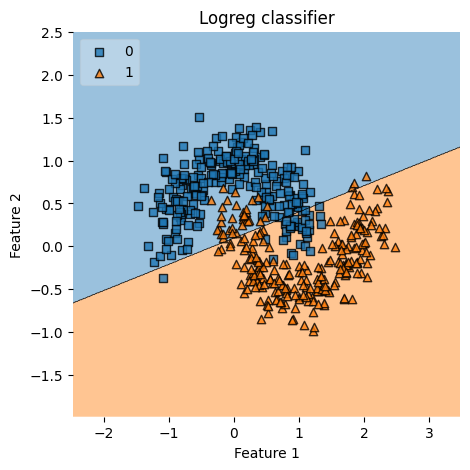

In [53]:
plot_decisions(moons_points, moons_labels, lr, 'Logreg classifier')

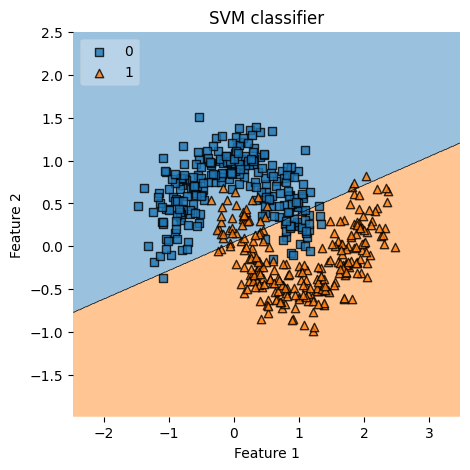

In [54]:
plot_decisions(moons_points, moons_labels, svm, 'SVM classifier')

Вывод:
Оба классификатора линейные, пытаются разделить данные линейной границей. Но данные явно имеют не линейную границу, а что-то типа спирали.
По точности +- одинаковые.

## 1.2 Kernel tirck

Now use different kernels (`poly`, `rbf`, `sigmoid`) on SVC to get better results. Play `degree` parameter and others.

For each kernel estimate optimal params, plot decision regions, calculate metric you've chosen eariler.

Write couple of sentences on:

* What have happenned with classification quality?
* How did decision border changed for each kernel?
* What `degree` have you chosen and why?

In [ ]:
### YOUR CODE HERE

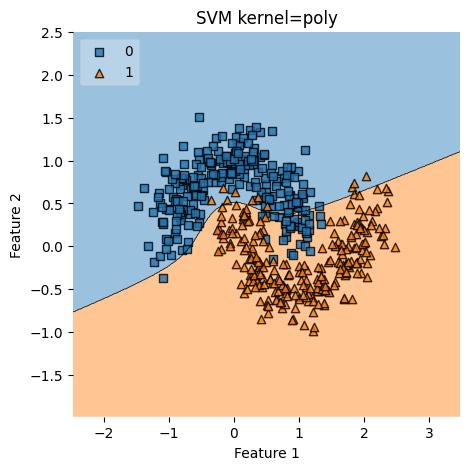

Kernel poly, accuracy svm: 0.906


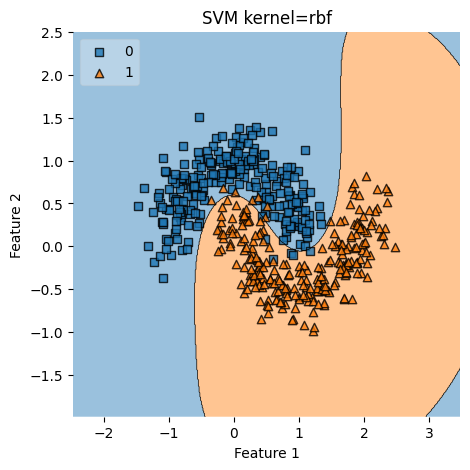

Kernel rbf, accuracy svm: 0.974


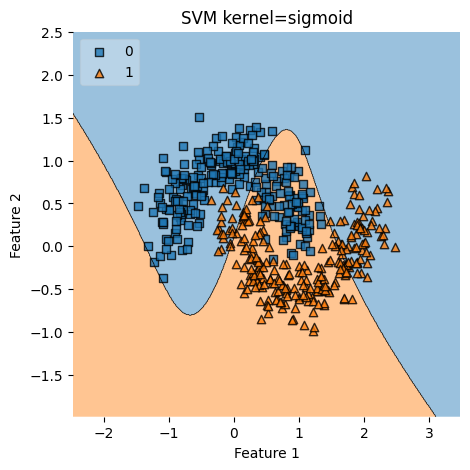

Kernel sigmoid, accuracy svm: 0.648


In [55]:
kernels = ["poly", "rbf", "sigmoid"]
for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(moons_points, moons_labels)
    plot_decisions(moons_points, moons_labels, svm, f'SVM kernel={kernel}')
    y_pred_svm = svm.predict(moons_points)
    acc_svm = accuracy_score(moons_labels, y_pred_svm)
    print(f'Kernel {kernel}, accuracy svm: {acc_svm}')

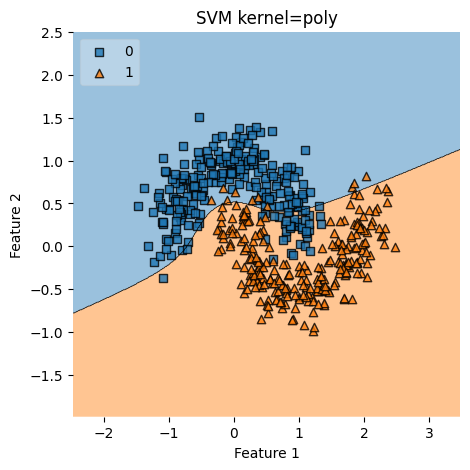

Kernel poly, accuracy svm: 0.898


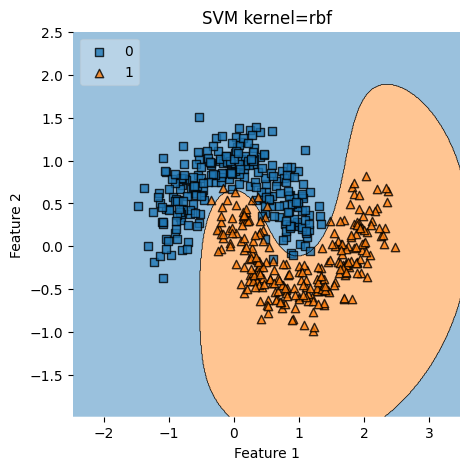

Kernel rbf, accuracy svm: 0.98


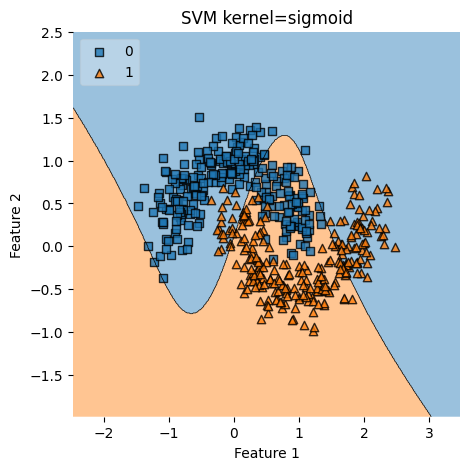

Kernel sigmoid, accuracy svm: 0.644


In [56]:
kernels = ["poly", "rbf", "sigmoid"]
for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42, C=5.0)
    svm.fit(moons_points, moons_labels)
    plot_decisions(moons_points, moons_labels, svm, f'SVM kernel={kernel}')
    y_pred_svm = svm.predict(moons_points)
    acc_svm = accuracy_score(moons_labels, y_pred_svm)
    print(f'Kernel {kernel}, accuracy svm: {acc_svm}')

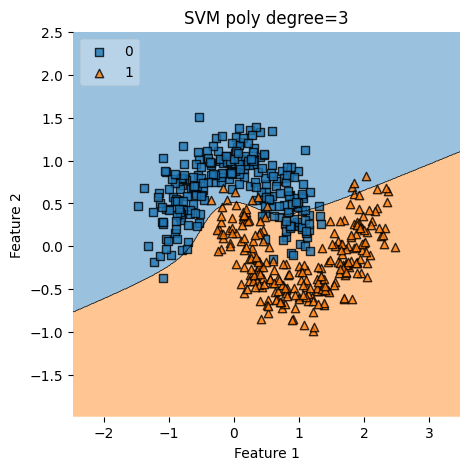

Kernel poly, degree 3, accuracy svm: 0.906


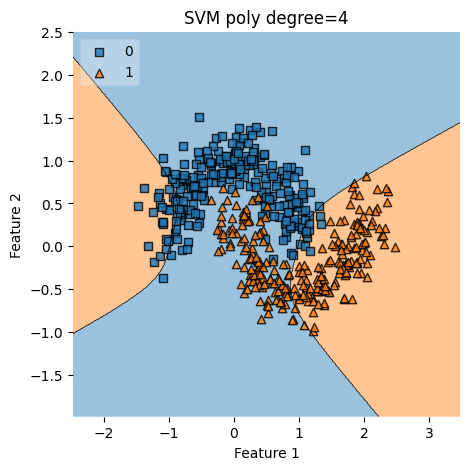

Kernel poly, degree 4, accuracy svm: 0.692


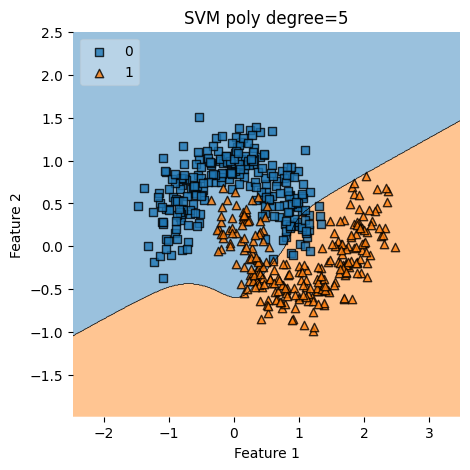

Kernel poly, degree 5, accuracy svm: 0.804


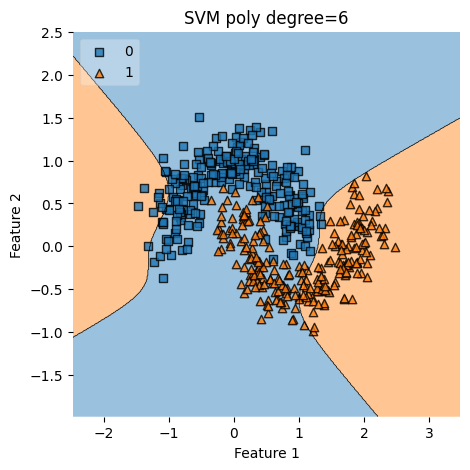

Kernel poly, degree 6, accuracy svm: 0.726


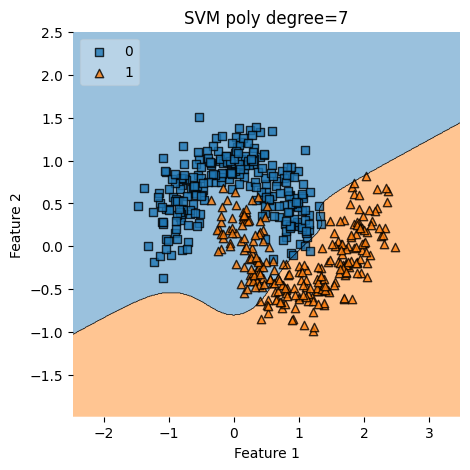

Kernel poly, degree 7, accuracy svm: 0.816


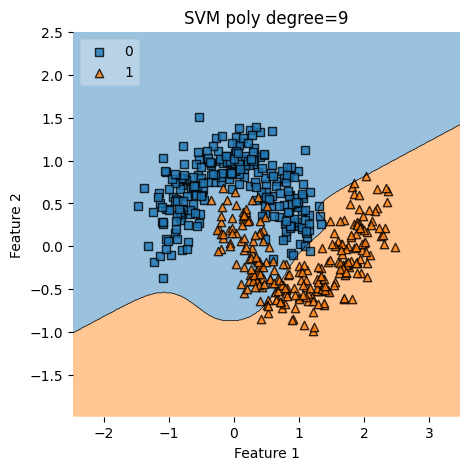

Kernel poly, degree 9, accuracy svm: 0.81


In [57]:
degrees = [3, 4, 5, 6, 7, 9]
for degree in degrees:
    svm = SVC(kernel='poly', degree=degree, random_state=42)
    svm.fit(moons_points, moons_labels)
    plot_decisions(moons_points, moons_labels, svm, f'SVM poly degree={degree}')
    y_pred_svm = svm.predict(moons_points)
    acc_svm = accuracy_score(moons_labels, y_pred_svm)
    print(f'Kernel poly, degree {degree}, accuracy svm: {acc_svm}')

Вывод:
1. Теперь граница раздела нелинейная. Лучше всего качество у kernel=rbf и она очень похожа на то, как выглядят данные.
2. По степени у kernel='poly' лучший рещультат дает дефолтное значение 3. Более высокие нечетные степени переобучаются, у границы появляются локальные выбросы, но глобально она не становится лучше. Четные степени здесь не подходят, они пытаются симметрично зафиттить еще один кусок данных, которого нет.


## 1.3 Simpler solution (of a kind)
What is we could use Logisitc Regression to successfully solve this task?

Feature generation is a thing to help here. Different techniques of feature generation are used in real life, couple of them will be covered in additional lectures.

In particular case simple `PolynomialFeatures` ([link](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)) are able to save the day.

Generate the set of new features, train LR on it, plot decision regions, calculate metric.

* Comare SVM's results with this solution (quality, borders type)
* What degree of PolynomialFeatures have you used? Compare with same SVM kernel parameter.

In [26]:
from sklearn.preprocessing import PolynomialFeatures

### YOUR CODE HERE

In [31]:
from sklearn.pipeline import Pipeline

In [58]:
lr_poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3, include_bias=False)),
    ('logistic_regression', LogisticRegression(solver='liblinear', random_state=42))
])

In [59]:
lr_poly_pipeline.fit(moons_points, moons_labels)


Pipeline(steps=[('poly_features',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('logistic_regression',
                 LogisticRegression(random_state=42, solver='liblinear'))])

In [60]:
y_pred_poly = lr_poly_pipeline.predict(moons_points)
acc_poly = accuracy_score(moons_labels, y_pred_poly)
print(f'Accuracy poly: {acc_poly}')

Accuracy poly: 0.964


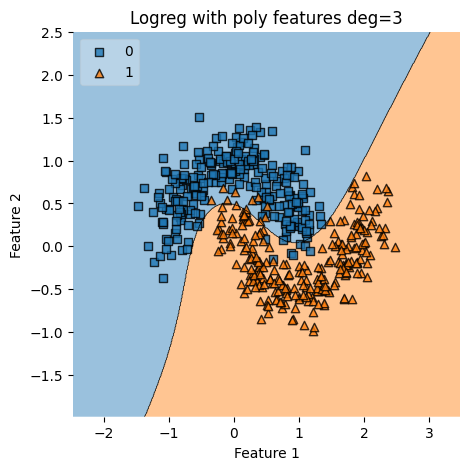

In [61]:
plot_decisions(moons_points, moons_labels, lr_poly_pipeline, f'Logreg with poly features deg=3')

Выводы:
1. При степени=3 граница и точность получились хорошие. Лучше, чем у SVM poly с такой же степенью (0.964 против 0.906). Но хуже, чем SVM с ядром rbf (0.98).

## 1.4 Harder problem

Let's make this task a bit more challenging via upgrading dataset:

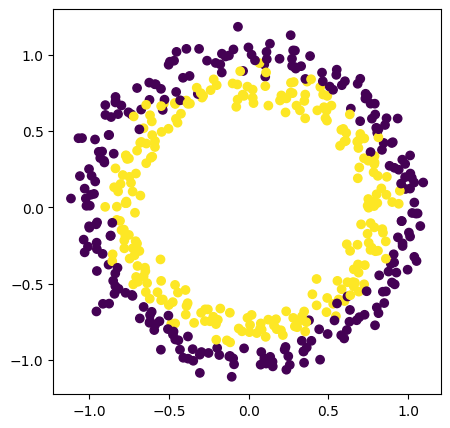

In [62]:
from sklearn.datasets import make_circles

circles_points, circles_labels = make_circles(n_samples=500, noise=0.06, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(circles_points[:, 0], circles_points[:, 1], c=circles_labels)

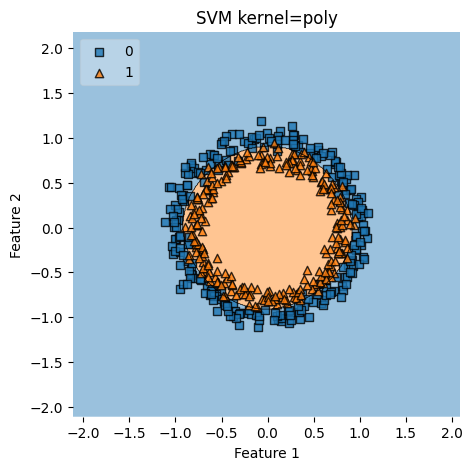

Kernel poly, accuracy svm: 0.938


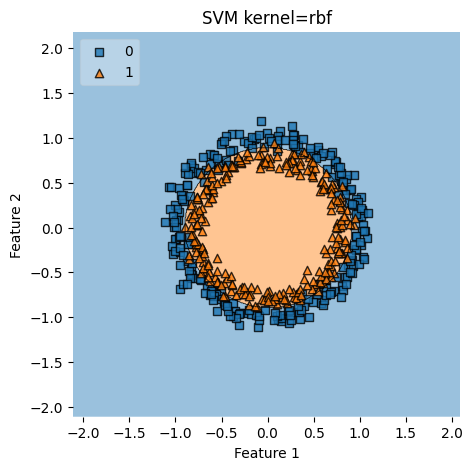

Kernel rbf, accuracy svm: 0.932


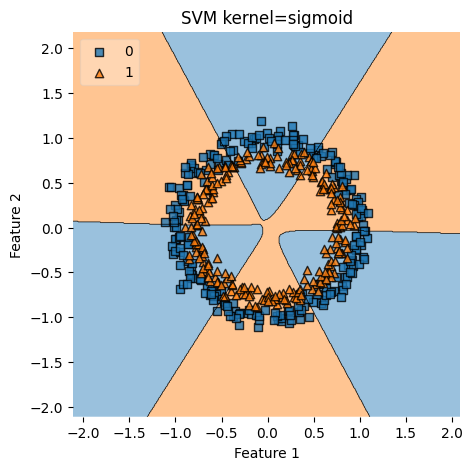

Kernel sigmoid, accuracy svm: 0.508


In [63]:
kernels = ["poly", "rbf", "sigmoid"]
for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42, degree=4)
    svm.fit(circles_points, circles_labels)
    plot_decisions(circles_points, circles_labels, svm, f'SVM kernel={kernel}')
    y_pred_svm = svm.predict(circles_points)
    acc_svm = accuracy_score(circles_labels, y_pred_svm)
    print(f'Kernel {kernel}, accuracy svm: {acc_svm}')

Accuracy poly: 0.93


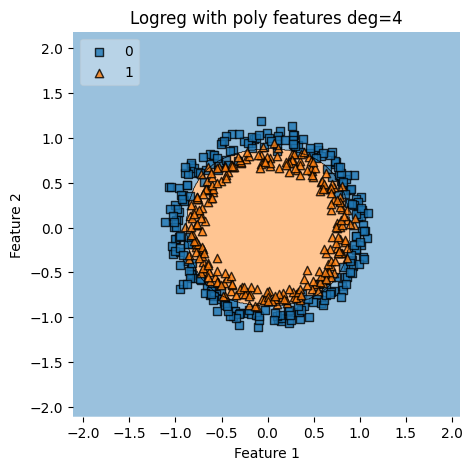

In [64]:
degree = 4
lr_poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('logistic_regression', LogisticRegression(solver='liblinear', random_state=42))
])
lr_poly_pipeline.fit(circles_points, circles_labels)
y_pred_poly = lr_poly_pipeline.predict(circles_points)
acc_poly = accuracy_score(circles_labels, y_pred_poly)
print(f'Accuracy poly: {acc_poly}')
plot_decisions(circles_points, circles_labels, lr_poly_pipeline, f'Logreg with poly features deg={degree}')

Выводы:
1. Для этих данных хорошо подошел SVM со степенью=4 и rbf. sigmoid опять плохо.
2. В случае логистической регрессии степень 4 также хорошо подходит.

And even more:

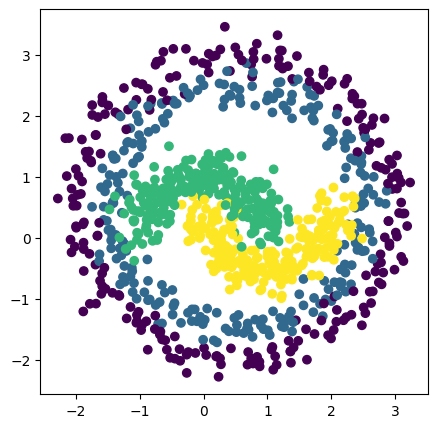

In [65]:
points = np.vstack((circles_points*2.5 + 0.5, moons_points))
labels = np.hstack((circles_labels, moons_labels + 2)) # + 2 to distinct moons classes

plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1], c=labels)

Now do your best using all the approaches above!

Tune LR with generated features, SVM with appropriate kernel of your choice. You may add some of your loved models to demonstrate their (and your) strength. Again plot decision regions, calculate metric.

Justify the results in a few phrases.

In [66]:
### YOUR CODE HERE

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


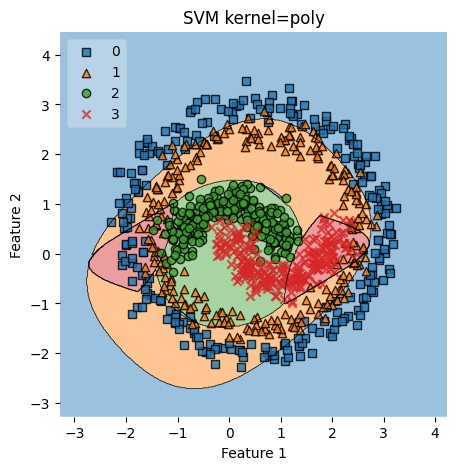

Kernel poly, accuracy svm: 0.666


/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


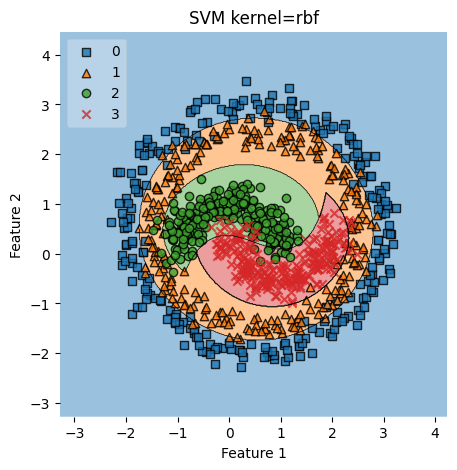

Kernel rbf, accuracy svm: 0.921


/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


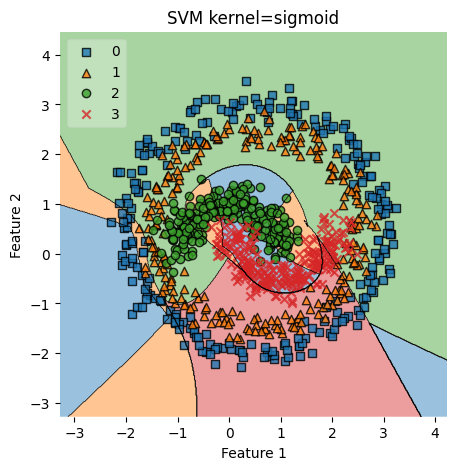

Kernel sigmoid, accuracy svm: 0.118


In [67]:
kernels = ["poly", "rbf", "sigmoid"]
for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42, degree=4)
    svm.fit(points, labels)
    plot_decisions(points, labels, svm, f'SVM kernel={kernel}')
    y_pred_svm = svm.predict(points)
    acc_svm = accuracy_score(labels, y_pred_svm)
    print(f'Kernel {kernel}, accuracy svm: {acc_svm}')

Accuracy poly: 0.929


/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


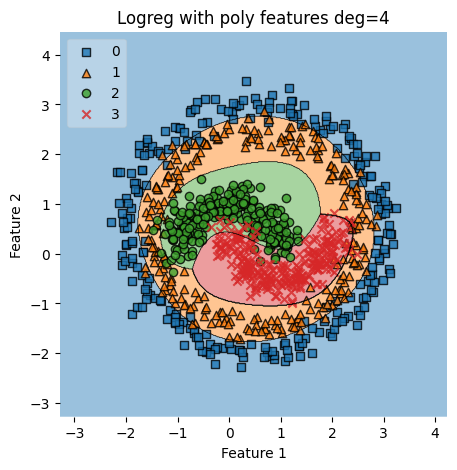

In [68]:
degree = 4
lr_poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('logistic_regression', LogisticRegression(solver='liblinear', random_state=42))
])
lr_poly_pipeline.fit(points, labels)
y_pred_poly = lr_poly_pipeline.predict(points)
acc_poly = accuracy_score(labels, y_pred_poly)
print(f'Accuracy poly: {acc_poly}')
plot_decisions(points, labels, lr_poly_pipeline, f'Logreg with poly features deg={degree}')

Accuracy poly: 0.939


/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


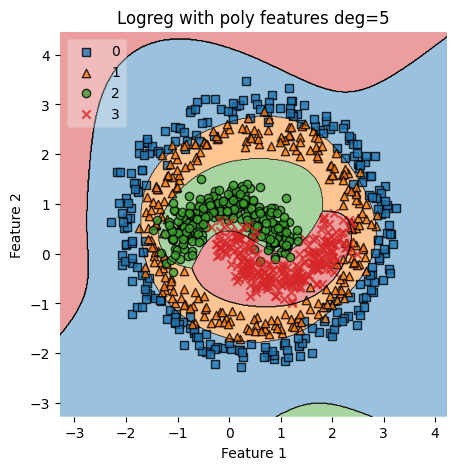

In [69]:
degree = 5
lr_poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('logistic_regression', LogisticRegression(solver='liblinear', random_state=42))
])
lr_poly_pipeline.fit(points, labels)
y_pred_poly = lr_poly_pipeline.predict(points)
acc_poly = accuracy_score(labels, y_pred_poly)
print(f'Accuracy poly: {acc_poly}')
plot_decisions(points, labels, lr_poly_pipeline, f'Logreg with poly features deg={degree}')

Выводы:
1. Для этих из вариантов SVM лучше всего отработал rbf.
2. В случае логистической регрессии степень 4 снова хорошо подходит.